# Step 1 - Define the problem

- We have been given mushroom dataset where we need to find out whether the mushroom is edibale or poisonous based on their characterstics.

# Step 2 - Collect and Prepare Data(EDA)

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
mushroom_df=pd.read_csv('mushroom.csv')

In [3]:
mushroom_df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [4]:
mushroom_df.shape

(2000, 26)

In [5]:
mushroom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [6]:
mushroom_df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


### Step 2.1.2 check the distinct values in each column                   

In [7]:
mushroom_df['cap_shape'].unique()



array(['sunken', 'flat', 'bell', 'convex', 'conical'], dtype=object)

In [8]:
mushroom_df['cap_surface'].unique()

array(['scaly', 'fibrous', 'grooves', 'smooth'], dtype=object)

In [9]:
for i in mushroom_df.select_dtypes(include='object').columns:
    print(i, mushroom_df[i].unique())

cap_shape ['sunken' 'flat' 'bell' 'convex' 'conical']
cap_surface ['scaly' 'fibrous' 'grooves' 'smooth']
cap_color ['white' 'red' 'purple' 'pink' 'yellow' 'brown' 'green' 'buff' 'gray']
bruises ['no' 'yes']
odor ['anise' 'foul' 'fishy' 'musty' 'spicy' 'none' 'pungent' 'almond'
 'creosote']
gill_attachment ['descending' 'notched' 'free' 'attached']
gill_spacing ['distant' 'crowded' 'close']
gill_size ['broad' 'narrow']
gill_color ['pink' 'chocolate' 'purple' 'orange' 'buff' 'black' 'red' 'green' 'brown'
 'yellow' 'white' 'gray']
stalk_shape ['tapering' 'enlarging']
stalk_root ['cup' 'rooted' 'club' 'missing' 'equal' 'bulbous' 'rhizomorphs']
stalk_surface_above_ring ['smooth' 'silky' 'scaly' 'fibrous']
stalk_surface_below_ring ['silky' 'scaly' 'smooth' 'fibrous']
stalk_color_above_ring ['gray' 'cinnamon' 'yellow' 'white' 'red' 'buff' 'orange' 'brown' 'pink']
stalk_color_below_ring ['yellow' 'brown' 'gray' 'pink' 'white' 'red' 'orange' 'buff' 'cinnamon']
veil_type ['partial' 'universal']


In [10]:
for col in mushroom_df.select_dtypes(include='object').columns:
    values = ", ".join(map(str, mushroom_df[col].unique()))
    print(f"{col} : {values}")

cap_shape : sunken, flat, bell, convex, conical
cap_surface : scaly, fibrous, grooves, smooth
cap_color : white, red, purple, pink, yellow, brown, green, buff, gray
bruises : no, yes
odor : anise, foul, fishy, musty, spicy, none, pungent, almond, creosote
gill_attachment : descending, notched, free, attached
gill_spacing : distant, crowded, close
gill_size : broad, narrow
gill_color : pink, chocolate, purple, orange, buff, black, red, green, brown, yellow, white, gray
stalk_shape : tapering, enlarging
stalk_root : cup, rooted, club, missing, equal, bulbous, rhizomorphs
stalk_surface_above_ring : smooth, silky, scaly, fibrous
stalk_surface_below_ring : silky, scaly, smooth, fibrous
stalk_color_above_ring : gray, cinnamon, yellow, white, red, buff, orange, brown, pink
stalk_color_below_ring : yellow, brown, gray, pink, white, red, orange, buff, cinnamon
veil_type : partial, universal
veil_color : brown, yellow, white, orange
ring_number : two, none, one
ring_type : sheathing, cobwebby, n

In [11]:
mushroom_df['stalk_height'].max(),mushroom_df['stalk_height'].min(),mushroom_df['cap_diameter'].max(),mushroom_df['cap_diameter'].min()	

(15.095065892005046, 2.0, 25.000053842997023, 1.0)

### Step 2.1.3 Check data types: numerical, categorical, datetime,remove unwanted columns and rows, remove duplicate rows, convert the datatype etc.

In [12]:
mushroom_df.duplicated().sum()

np.int64(1024)

In [13]:
mushroom_df.duplicated().value_counts()

True     1024
False     976
Name: count, dtype: int64

In [14]:
mushroom_df[mushroom_df.duplicated()].sort_values(by='Unnamed: 0',ascending=True)

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
1093,0,bell,scaly,pink,yes,anise,free,close,broad,red,...,partial,brown,two,pendant,black,several,leaves,poisonous,12.349476,20.520120
604,0,bell,scaly,pink,yes,anise,free,close,broad,red,...,partial,brown,two,pendant,black,several,leaves,poisonous,12.349476,20.520120
1405,0,bell,scaly,pink,yes,anise,free,close,broad,red,...,partial,brown,two,pendant,black,several,leaves,poisonous,12.349476,20.520120
1960,1,conical,scaly,gray,no,fishy,free,close,broad,pink,...,universal,brown,none,pendant,black,abundant,waste,edible,13.802729,4.730802
870,2,flat,smooth,brown,no,foul,attached,distant,broad,orange,...,partial,yellow,two,cobwebby,chocolate,several,waste,poisonous,3.628180,9.636546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,1277,flat,scaly,brown,yes,foul,notched,distant,narrow,purple,...,universal,white,one,pendant,buff,abundant,meadows,poisonous,3.708788,18.958465
1770,1277,flat,scaly,brown,yes,foul,notched,distant,narrow,purple,...,universal,white,one,pendant,buff,abundant,meadows,poisonous,3.708788,18.958465
1599,1279,bell,smooth,pink,no,foul,notched,distant,broad,pink,...,universal,brown,one,zone,black,scattered,leaves,poisonous,5.291009,5.436304
1765,1279,bell,smooth,pink,no,foul,notched,distant,broad,pink,...,universal,brown,one,zone,black,scattered,leaves,poisonous,5.291009,5.436304


In [15]:
mushroom_df1=mushroom_df.drop_duplicates(keep='first')

In [16]:
mushroom_df1.shape

(976, 26)

In [17]:
mushroom_df1.duplicated().sum()

np.int64(0)

In [18]:
mushroom_df1.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


##  Step 2.3 - Analyze Target Variable – decide the target variable. Only check target feature behavior.

In [19]:
mushroom_df1['class'].value_counts()

class
poisonous    618
edible       358
Name: count, dtype: int64

- By looking at the above we can say that dataset is imbalanced

<Axes: xlabel='class', ylabel='count'>

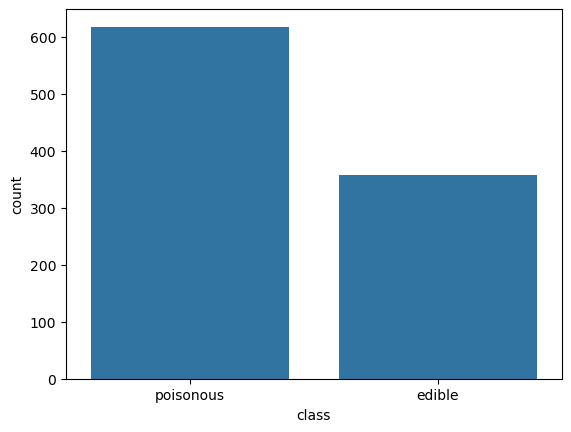

In [20]:
sns.countplot(mushroom_df1,x='class')

<Axes: xlabel='class'>

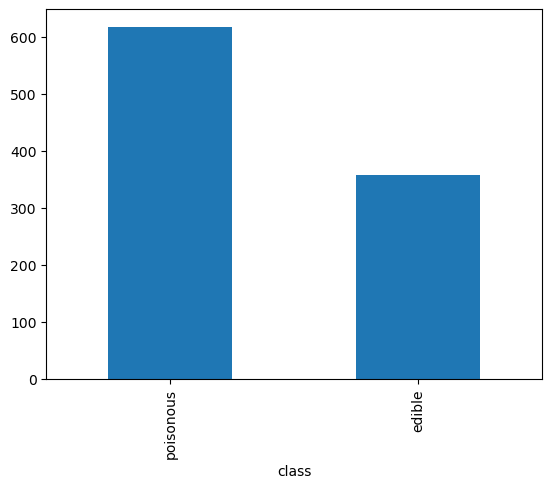

In [21]:
mushroom_df1['class'].value_counts().plot(kind='bar')

<Axes: xlabel='class', ylabel='cap_diameter'>

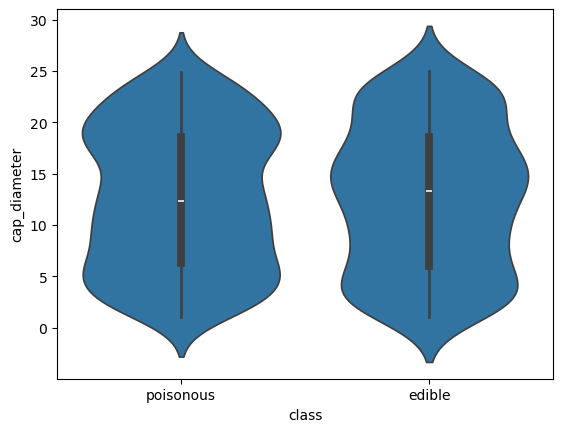

In [22]:
sns.violinplot(x='class', y='cap_diameter', data=mushroom_df1)

## Step 2.4 - Univariate Analysis (Single Variable)  - see the distribution/count/histogram of any one variable

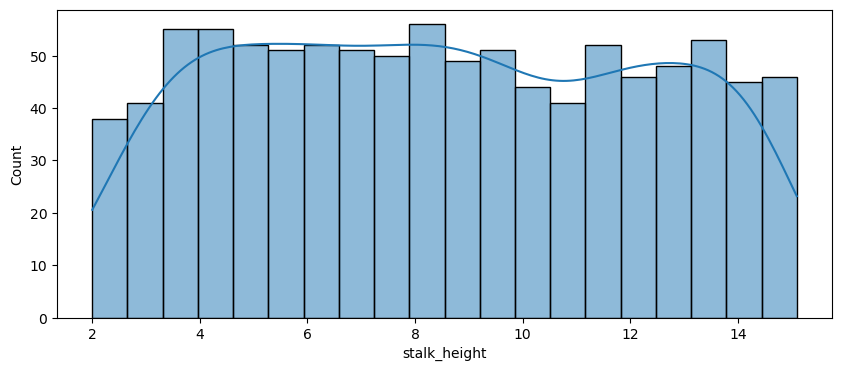

In [23]:
plt.figure(figsize=((10,4)))
sns.histplot(data=mushroom_df1,x='stalk_height',bins=20,kde=True)
plt.xlabel=('stalk_height')
plt.show()

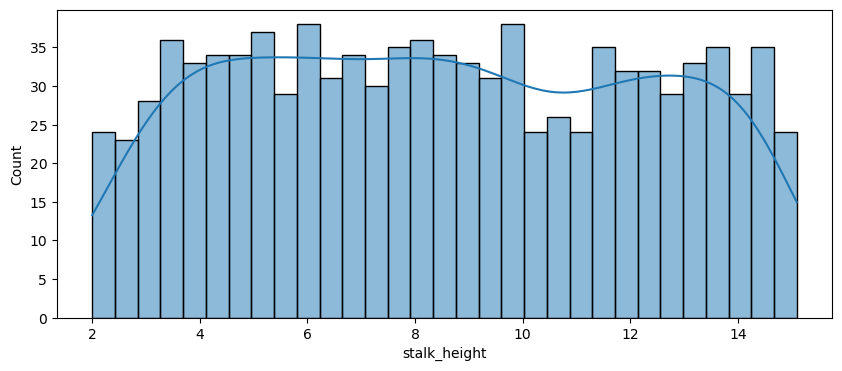

In [24]:
plt.figure(figsize=((10,4)))
sns.histplot(data=mushroom_df1,x='stalk_height',bins=31,kde=True)
plt.xlabel=('cap_diameter')
plt.show()

In [25]:
np.sqrt(len(mushroom_df1))

np.float64(31.240998703626616)

<Axes: ylabel='cap_surface'>

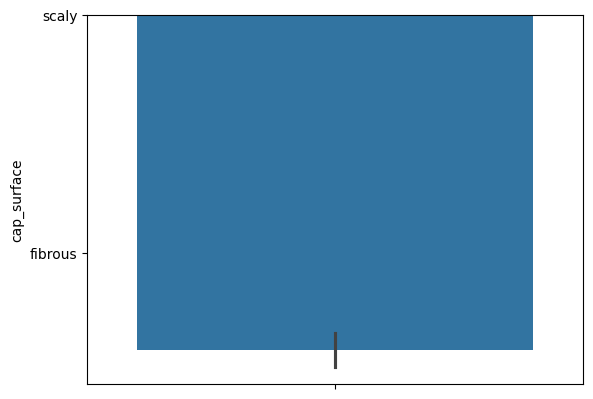

In [26]:
sns.barplot(mushroom_df1,y='cap_surface')

<Axes: xlabel='cap_surface', ylabel='count'>

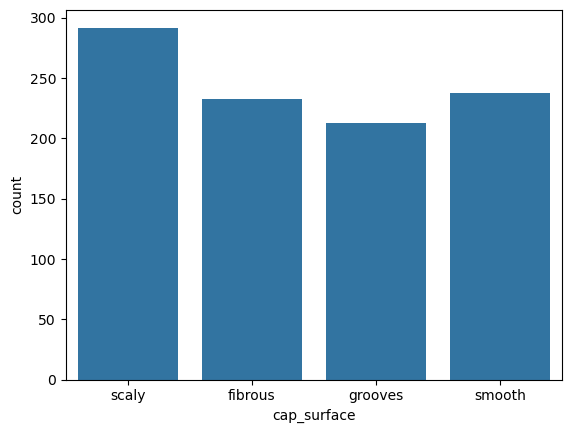

In [27]:
sns.countplot(mushroom_df1,x='cap_surface')

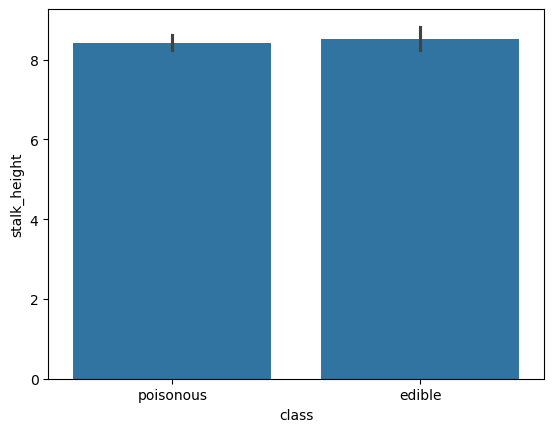

In [28]:
sns.barplot(x='class', y='stalk_height', data=mushroom_df,)
plt.show()

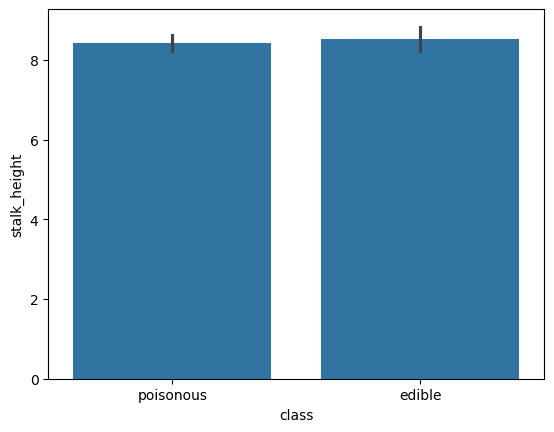

In [29]:
sns.barplot(x='class', y='stalk_height', data=mushroom_df,)
plt.show()

## Step 2.5 - Check for Missing Values 

In [30]:
mushroom_df1.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

- There are no missing values

##  Step 2.6 - Bivariate/Multivariate Analysis – compare any feature with target variable.

### Numerical vs target variable 

<Axes: xlabel='None', ylabel='stalk_height'>

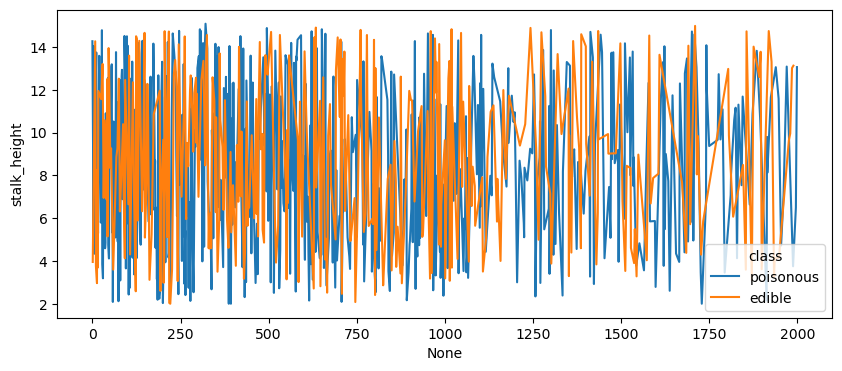

In [31]:
plt.figure(figsize=(10,4))
sns.lineplot(x=mushroom_df1.index, y='stalk_height', data=mushroom_df1,hue='class')

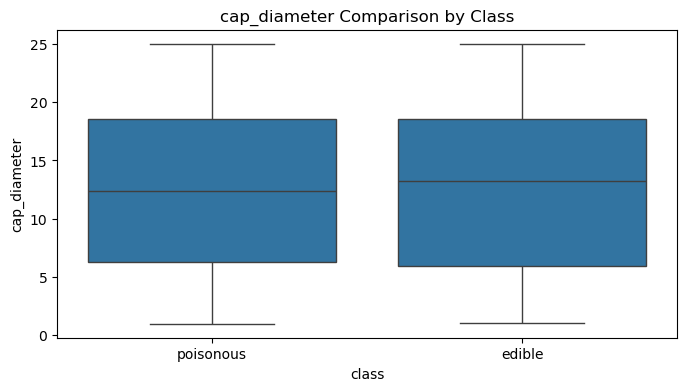

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x='class', y='cap_diameter', data=mushroom_df1)
plt.title("cap_diameter Comparison by Class")
plt.show()

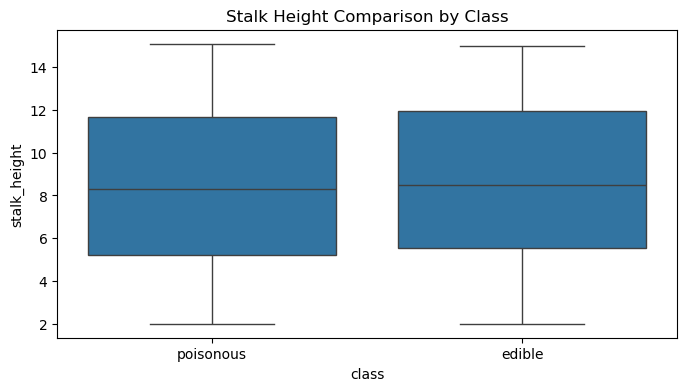

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x='class', y='stalk_height', data=mushroom_df1)
plt.title("Stalk Height Comparison by Class")
plt.show()

- By looking at the above 2 graph we can say that both features are not playing imporatnt role to decide class of mushroom

In [154]:
mushroom_df1.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,stalk_root,stalk_surface_above_ring,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,cup,smooth,silky,gray,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,rooted,silky,silky,cinnamon,brown,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,cup,scaly,silky,yellow,gray,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,club,smooth,scaly,yellow,pink,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,missing,fibrous,scaly,gray,white,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [158]:
mushroom_df1['class'].value_counts()
#mushroom_df[['poisonous']].value_counts()

class
poisonous    618
edible       358
Name: count, dtype: int64

### Categorical vs target variable

In [34]:
pd.crosstab(mushroom_df1['odor'], mushroom_df1['class'])

class,edible,poisonous
odor,,
almond,37,61
anise,50,69
creosote,41,66
fishy,38,73
foul,44,82
musty,32,79
none,31,62
pungent,40,61
spicy,45,65


In [35]:
mushroom_df1[['class','odor']].value_counts()

class      odor    
poisonous  foul        82
           musty       79
           fishy       73
           anise       69
           creosote    66
           spicy       65
           none        62
           almond      61
           pungent     61
edible     anise       50
           spicy       45
           foul        44
           creosote    41
           pungent     40
           fishy       38
           almond      37
           musty       32
           none        31
Name: count, dtype: int64

<Axes: xlabel='odor'>

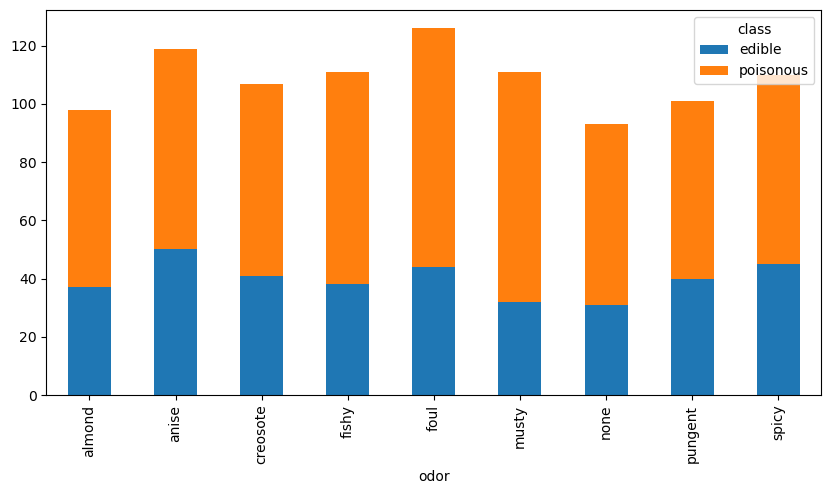

In [36]:
ct = pd.crosstab(mushroom_df1['odor'], mushroom_df1['class'])

ct.plot(kind='bar', stacked=True, figsize=(10,5))

<Axes: xlabel='odor'>

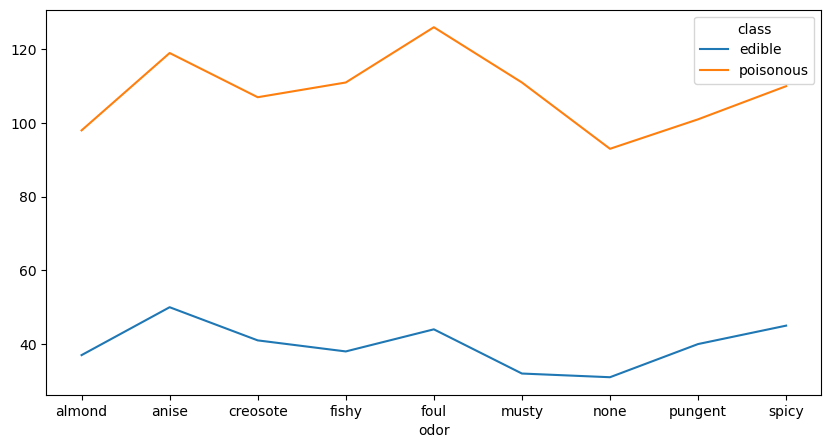

In [37]:
ct = pd.crosstab(mushroom_df1['odor'], mushroom_df1['class'])

ct.plot(kind='line', stacked=True, figsize=(10,5))

<Axes: xlabel='class', ylabel='odor'>

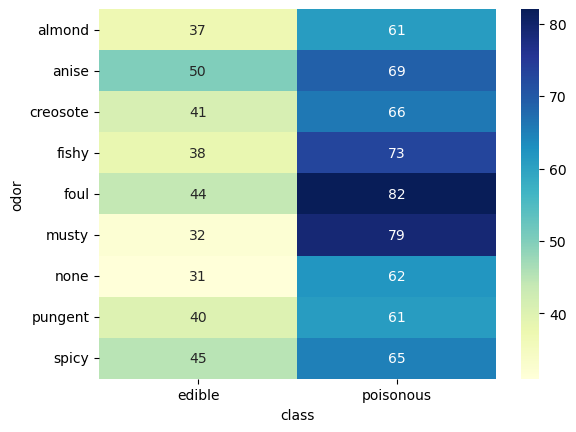

In [38]:
ct1 = pd.crosstab(mushroom_df1['class'], mushroom_df1['odor'])

sns.heatmap(ct, annot=True, cmap='YlGnBu', fmt='d')

#### Class Vs cap_surface

In [39]:
pd.crosstab(mushroom_df1['cap_surface'],mushroom_df1['class']) 

class,edible,poisonous
cap_surface,,
fibrous,72,161
grooves,80,133
scaly,119,173
smooth,87,151


#### Class Vs cap_color

In [40]:
pd.crosstab(mushroom_df1['cap_color'],mushroom_df1['class']) 

class,edible,poisonous
cap_color,,
brown,43,84
buff,32,72
gray,43,62
green,32,76
pink,46,66
purple,32,68
red,50,60
white,33,63
yellow,47,67


-- mushroom_df1.corr()

##  Step 2.7 - Outlier Detection

In [41]:
mushroom_df1.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [42]:
mushroom_df2=mushroom_df1.copy()

#### stalk_height

<Axes: xlabel='stalk_height', ylabel='Count'>

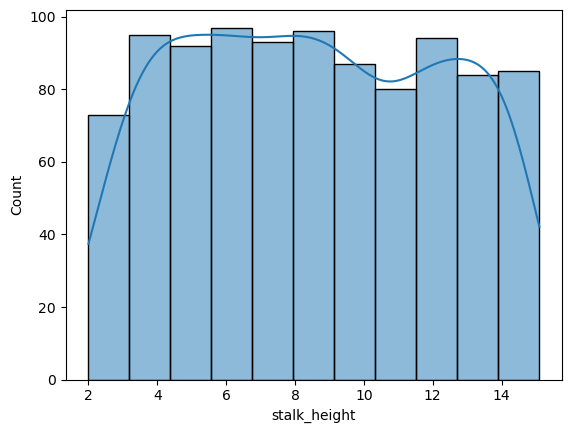

In [43]:
sns.histplot(mushroom_df2,x='stalk_height', kde=True)

- By looking at the above graph we can say that the distribution is iniform not the normal.
- So we need go for IQR method for outlier removal

<Axes: ylabel='stalk_height'>

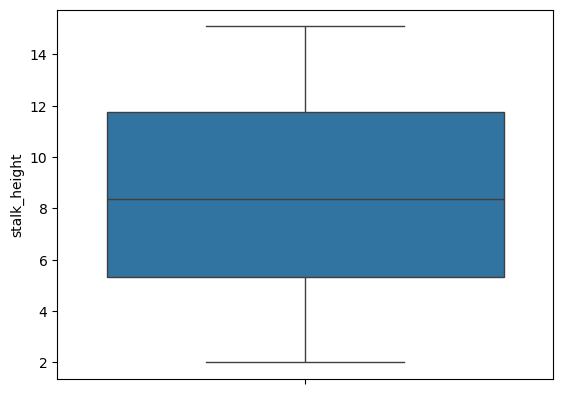

In [44]:
sns.boxplot(mushroom_df2,y='stalk_height')

- There are no outliers in stalk_height feature

### cap_diameter

<Axes: ylabel='cap_diameter'>

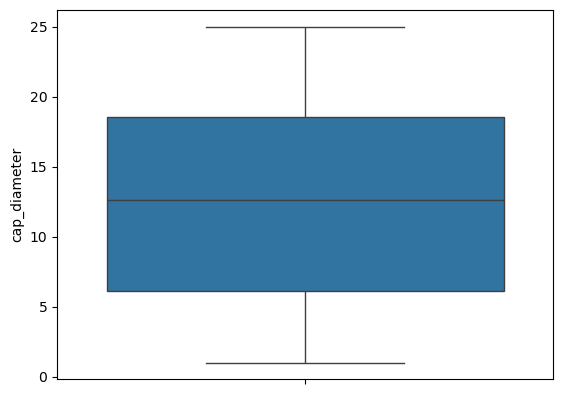

In [45]:
sns.boxplot(mushroom_df2,y='cap_diameter')

- There are no outliers in stalk_height feature

## Step 2.8 – Encoding the values

In [46]:
mushroom_df2.select_dtypes(include='object')

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,gray,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,cinnamon,brown,universal,brown,two,sheathing,brown,numerous,waste,edible
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,yellow,gray,universal,yellow,two,sheathing,purple,abundant,waste,poisonous
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,yellow,pink,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,gray,white,universal,white,none,none,yellow,clustered,urban,poisonous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,conical,grooves,brown,no,foul,notched,crowded,broad,chocolate,tapering,...,red,yellow,universal,brown,none,large,brown,numerous,paths,edible
1988,bell,grooves,pink,yes,anise,descending,distant,broad,brown,enlarging,...,pink,pink,partial,brown,two,pendant,yellow,numerous,grasses,poisonous
1989,sunken,smooth,purple,yes,anise,descending,crowded,narrow,buff,tapering,...,brown,red,universal,orange,two,none,orange,abundant,grasses,edible
1996,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,tapering,...,pink,orange,partial,white,one,zone,yellow,numerous,waste,poisonous


In [47]:
mushroom_df2['cap_shape'].unique() # as this  category does not any ordering so we can use one hot encoding

array(['sunken', 'flat', 'bell', 'convex', 'conical'], dtype=object)

In [48]:
pd.get_dummies(mushroom_df2['cap_shape'],drop_first='True').astype(int)

,conical,convex,flat,sunken
0,0,0,0,1
1,0,0,0,1
2,0,0,1,0
3,0,0,0,0
4,0,0,1,0
...,...,...,...,...
1985,1,0,0,0
1988,0,0,0,0
1989,0,0,0,1
1996,0,0,0,1


In [49]:
#pd.get_dummies(mushroom_df2,columns=['cap_shape'],drop_first=True).astype(int)

In [162]:
X1 = mushroom_df2.drop('class', axis=1)   # features
y1 = mushroom_df2['class']               # target

# Encode features
X_encoded = pd.get_dummies(X1, drop_first=True).astype(int)

# Encode target
y_encoded = y1.map({'poisonous': 1, 'edible': 0})

# Combine
mushroom_df33 = pd.concat([X_encoded, y_encoded], axis=1)

In [167]:
mushroom_df33.dtypes
#mushroom_df4.dtypes


Unnamed: 0           int64
stalk_height         int64
cap_diameter         int64
cap_shape_conical    int64
cap_shape_convex     int64
                     ...  
habitat_paths        int64
habitat_urban        int64
habitat_waste        int64
habitat_woods        int64
class                int64
Length: 106, dtype: object

In [163]:
mushroom_df33.head()

,Unnamed: 0,stalk_height,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,bruises_yes,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,veil_type_universal,veil_color_orange,veil_color_white,veil_color_yellow,ring_number_one,ring_number_two,ring_type_evanescent,ring_type_flaring,ring_type_large,ring_type_none,ring_type_pendant,ring_type_sheathing,ring_type_zone,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,population_clustered,population_numerous,population_scattered,population_several,population_solitary,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,1167,14,5,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,1037,3,19,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,309,9,7,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,282,5,20,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,820,14,12,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1


In [168]:
mushroom_df3=mushroom_df33.copy()

In [170]:
mushroom_df3.head()

,Unnamed: 0,stalk_height,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,bruises_yes,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,veil_type_universal,veil_color_orange,veil_color_white,veil_color_yellow,ring_number_one,ring_number_two,ring_type_evanescent,ring_type_flaring,ring_type_large,ring_type_none,ring_type_pendant,ring_type_sheathing,ring_type_zone,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,population_clustered,population_numerous,population_scattered,population_several,population_solitary,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,1167,14,5,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,1037,3,19,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,309,9,7,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,282,5,20,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,820,14,12,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1


In [171]:
for i in mushroom_df3.columns:
    print(i)

Unnamed: 0
stalk_height
cap_diameter
cap_shape_conical
cap_shape_convex
cap_shape_flat
cap_shape_sunken
cap_surface_grooves
cap_surface_scaly
cap_surface_smooth
cap_color_buff
cap_color_gray
cap_color_green
cap_color_pink
cap_color_purple
cap_color_red
cap_color_white
cap_color_yellow
bruises_yes
odor_anise
odor_creosote
odor_fishy
odor_foul
odor_musty
odor_none
odor_pungent
odor_spicy
gill_attachment_descending
gill_attachment_free
gill_attachment_notched
gill_spacing_crowded
gill_spacing_distant
gill_size_narrow
gill_color_brown
gill_color_buff
gill_color_chocolate
gill_color_gray
gill_color_green
gill_color_orange
gill_color_pink
gill_color_purple
gill_color_red
gill_color_white
gill_color_yellow
stalk_shape_tapering
stalk_root_club
stalk_root_cup
stalk_root_equal
stalk_root_missing
stalk_root_rhizomorphs
stalk_root_rooted
stalk_surface_above_ring_scaly
stalk_surface_above_ring_silky
stalk_surface_above_ring_smooth
stalk_surface_below_ring_scaly
stalk_surface_below_ring_silky
stalk_

## Step 2.9 - Feature Scaling

- As we have seen features stalk_height,	cap_diameter both are not having uniform distribution so we need to use normalisation not the standardisation.

In [172]:
mushroom_df4=mushroom_df3.copy()

In [173]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
normaliser = MinMaxScaler()

In [174]:
columns=['stalk_height', 'cap_diameter']

In [175]:
mushroom_df4[columns]=normaliser.fit_transform(mushroom_df4[columns])

In [176]:
mushroom_df4.head()

,Unnamed: 0,stalk_height,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,bruises_yes,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,veil_type_universal,veil_color_orange,veil_color_white,veil_color_yellow,ring_number_one,ring_number_two,ring_type_evanescent,ring_type_flaring,ring_type_large,ring_type_none,ring_type_pendant,ring_type_sheathing,ring_type_zone,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,population_clustered,population_numerous,population_scattered,population_several,population_solitary,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,1167,0.923077,0.166667,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,1037,0.076923,0.750000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,309,0.538462,0.250000,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,282,0.230769,0.791667,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,820,0.923077,0.458333,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1


In [177]:
mushroom_df4['stalk_height'].max(),mushroom_df4['stalk_height'].min()

(1.0, 0.0)

In [178]:
mushroom_df4['cap_diameter'].max(),mushroom_df4['cap_diameter'].min()

(0.9999999999999999, 0.0)

##  Step 2.11 – Feature selection 

In [179]:
mushroom_df4.head()


,Unnamed: 0,stalk_height,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,bruises_yes,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,veil_type_universal,veil_color_orange,veil_color_white,veil_color_yellow,ring_number_one,ring_number_two,ring_type_evanescent,ring_type_flaring,ring_type_large,ring_type_none,ring_type_pendant,ring_type_sheathing,ring_type_zone,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,population_clustered,population_numerous,population_scattered,population_several,population_solitary,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,1167,0.923077,0.166667,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,1037,0.076923,0.750000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,309,0.538462,0.250000,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,282,0.230769,0.791667,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,820,0.923077,0.458333,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1


In [180]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [181]:
mushroom_df4.dtypes

Unnamed: 0             int64
stalk_height         float64
cap_diameter         float64
cap_shape_conical      int64
cap_shape_convex       int64
                      ...   
habitat_paths          int64
habitat_urban          int64
habitat_waste          int64
habitat_woods          int64
class                  int64
Length: 106, dtype: object

In [182]:
x=mushroom_df4.iloc[:,:-1]
y=mushroom_df4.iloc[:,-1]

In [183]:
x.shape,y.shape

((976, 105), (976,))

In [184]:

from sklearn.feature_selection import SelectKBest,chi2,f_regression,f_classif
skbasemodel=SelectKBest(k=10,score_func=f_classif)

In [185]:
skbasemodel # model created

SelectKBest()

In [186]:
selected_features=skbasemodel.fit_transform(x,y) # lets train the model

In [187]:
skbasemodel.get_support()

array([False, False, False, False, False, False, False, False,  True,
       False, False, False,  True, False, False,  True, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False,  True, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False])

In [188]:
skbasemodel.get_feature_names_out()  # This will only column list which we had requested(k=10)

array(['cap_surface_scaly', 'cap_color_green', 'cap_color_red',
       'odor_musty', 'gill_color_orange', 'gill_color_purple',
       'stalk_root_cup', 'stalk_color_below_ring_gray',
       'spore_print_color_brown', 'habitat_leaves'], dtype=object)

In [189]:
skbasemodel.scores_ # this will retun scores for all features from that we need to find top 10(already that is done aboce)

array([4.47559011e-01, 1.37738519e+00, 6.45106834e-02, 1.18869833e-03,
       1.98356751e-01, 9.75348387e-01, 8.00835460e-02, 9.03285699e-02,
       2.97913121e+00, 2.13708006e-03, 1.75073358e+00, 9.23513192e-01,
       2.60083926e+00, 1.04931478e+00, 1.04979228e+00, 4.11823459e+00,
       2.43192107e-01, 1.14838661e+00, 6.12880070e-02, 1.66112709e+00,
       1.38464314e-01, 3.22094798e-01, 1.92529967e-01, 3.32874741e+00,
       4.95039688e-01, 4.13933437e-01, 9.53484248e-01, 5.20096332e-01,
       9.12835351e-02, 1.15019506e+00, 1.82439951e-01, 1.00791047e+00,
       3.84033268e-01, 1.26979005e+00, 1.48855139e-02, 9.37123079e-01,
       1.48855139e-02, 3.85694371e-01, 5.93045506e+00, 7.90668700e-02,
       3.20998154e+00, 3.40840811e-01, 3.46867351e-04, 2.24409636e-02,
       8.18222562e-01, 2.76141665e-01, 3.52766027e+00, 5.95225911e-03,
       3.56266719e-01, 1.17608902e+00, 7.35286027e-01, 2.35054790e-04,
       1.07496864e-01, 3.34547280e-03, 7.44380587e-01, 9.91030114e-02,
      

In [190]:
feat_imp=pd.DataFrame()
feat_imp['features']=x.columns
feat_imp['importances']=skbasemodel.scores_
feat_imp.sort_values(by='importances',ascending=False).head(10)

,features,importances
38,gill_color_orange,5.930455
67,stalk_color_below_ring_gray,4.950897
15,cap_color_red,4.118235
46,stalk_root_cup,3.527660
86,spore_print_color_brown,3.456139
23,odor_musty,3.328747
40,gill_color_purple,3.209982
8,cap_surface_scaly,2.979131
12,cap_color_green,2.600839
99,habitat_leaves,2.461954


- So the important feature select by k models are gill,stalk,cap,spore,odor,habitat. So we need use these 6 features to build the model

<Figure size 800x400 with 0 Axes>

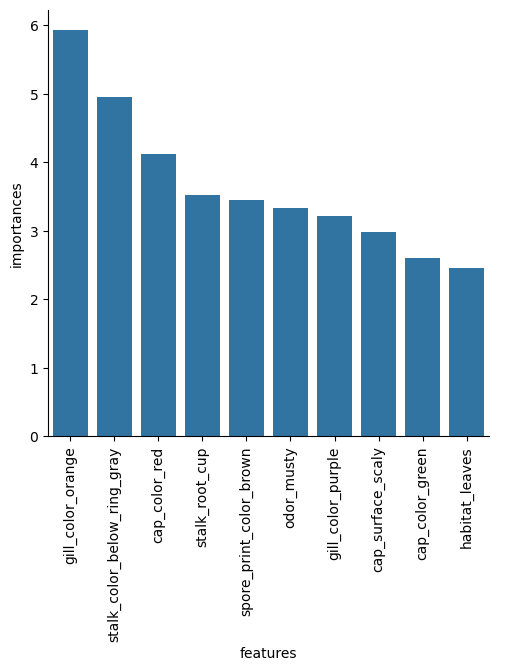

In [191]:
plt.figure(figsize=(8,4))
sns.catplot(feat_imp.sort_values(by='importances',ascending=False).head(10),x='features',y='importances',kind='bar')
plt.xticks(rotation=90)
plt.show()

In [192]:
mushroom_df4.head()

,Unnamed: 0,stalk_height,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,bruises_yes,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,veil_type_universal,veil_color_orange,veil_color_white,veil_color_yellow,ring_number_one,ring_number_two,ring_type_evanescent,ring_type_flaring,ring_type_large,ring_type_none,ring_type_pendant,ring_type_sheathing,ring_type_zone,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,population_clustered,population_numerous,population_scattered,population_several,population_solitary,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,1167,0.923077,0.166667,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,1037,0.076923,0.750000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,309,0.538462,0.250000,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1
3,282,0.230769,0.791667,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,820,0.923077,0.458333,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1


In [193]:
for i in mushroom_df4.columns:
    print(i)

Unnamed: 0
stalk_height
cap_diameter
cap_shape_conical
cap_shape_convex
cap_shape_flat
cap_shape_sunken
cap_surface_grooves
cap_surface_scaly
cap_surface_smooth
cap_color_buff
cap_color_gray
cap_color_green
cap_color_pink
cap_color_purple
cap_color_red
cap_color_white
cap_color_yellow
bruises_yes
odor_anise
odor_creosote
odor_fishy
odor_foul
odor_musty
odor_none
odor_pungent
odor_spicy
gill_attachment_descending
gill_attachment_free
gill_attachment_notched
gill_spacing_crowded
gill_spacing_distant
gill_size_narrow
gill_color_brown
gill_color_buff
gill_color_chocolate
gill_color_gray
gill_color_green
gill_color_orange
gill_color_pink
gill_color_purple
gill_color_red
gill_color_white
gill_color_yellow
stalk_shape_tapering
stalk_root_club
stalk_root_cup
stalk_root_equal
stalk_root_missing
stalk_root_rhizomorphs
stalk_root_rooted
stalk_surface_above_ring_scaly
stalk_surface_above_ring_silky
stalk_surface_above_ring_smooth
stalk_surface_below_ring_scaly
stalk_surface_below_ring_silky
stalk_

In [195]:
mushroom_df5=mushroom_df4[['cap_diameter','cap_shape_conical','cap_shape_convex','cap_shape_flat','cap_shape_sunken','cap_surface_grooves','cap_surface_scaly','cap_surface_smooth','cap_color_buff','cap_color_gray','cap_color_green','cap_color_pink','cap_color_purple','cap_color_red','cap_color_white','cap_color_yellow','stalk_height','stalk_shape_tapering','stalk_root_club','stalk_root_cup','stalk_root_equal','stalk_root_missing','stalk_root_rhizomorphs','stalk_root_rooted','stalk_surface_above_ring_scaly','stalk_surface_above_ring_silky','stalk_surface_above_ring_smooth','stalk_surface_below_ring_scaly','stalk_surface_below_ring_silky','stalk_surface_below_ring_smooth','stalk_color_above_ring_buff','stalk_color_above_ring_cinnamon','stalk_color_above_ring_gray','stalk_color_above_ring_orange','stalk_color_above_ring_pink','stalk_color_above_ring_red','stalk_color_above_ring_white','stalk_color_above_ring_yellow','stalk_color_below_ring_buff','stalk_color_below_ring_cinnamon','stalk_color_below_ring_gray','stalk_color_below_ring_orange','stalk_color_below_ring_pink','stalk_color_below_ring_red','stalk_color_below_ring_white','stalk_color_below_ring_yellow','odor_anise','odor_creosote','odor_fishy','odor_foul','odor_musty','odor_none','odor_pungent','odor_spicy','gill_attachment_descending','gill_attachment_free','gill_attachment_notched','gill_spacing_crowded','gill_spacing_distant','gill_size_narrow','gill_color_brown','gill_color_buff','gill_color_chocolate','gill_color_gray','gill_color_green','gill_color_orange','gill_color_pink','gill_color_purple','gill_color_red','gill_color_white','gill_color_yellow','spore_print_color_brown','spore_print_color_buff','spore_print_color_chocolate','spore_print_color_green','spore_print_color_orange','spore_print_color_purple','spore_print_color_white','spore_print_color_yellow','habitat_leaves','habitat_meadows','habitat_paths','habitat_urban','habitat_waste','habitat_woods','class']]

- Used only feature group which are having high importance

In [196]:
mushroom_df5.shape

(976, 86)

In [198]:
mushroom_df5.head()

,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,stalk_height,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,0.166667,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0.923077,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
1,0.750000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0.076923,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0.250000,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0.538462,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1
3,0.791667,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0.230769,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0.458333,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0.923077,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1


In [199]:
mushroom_df5[['cap_diameter','stalk_height']]

,cap_diameter,stalk_height
0,0.166667,0.923077
1,0.750000,0.076923
2,0.250000,0.538462
3,0.791667,0.230769
4,0.458333,0.923077
...,...,...
1985,0.333333,0.846154
1988,0.708333,0.076923
1989,0.583333,0.846154
1996,0.500000,0.307692


In [200]:
mushroom_df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 976 entries, 0 to 1999
Data columns (total 86 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   cap_diameter                     976 non-null    float64
 1   cap_shape_conical                976 non-null    int64  
 2   cap_shape_convex                 976 non-null    int64  
 3   cap_shape_flat                   976 non-null    int64  
 4   cap_shape_sunken                 976 non-null    int64  
 5   cap_surface_grooves              976 non-null    int64  
 6   cap_surface_scaly                976 non-null    int64  
 7   cap_surface_smooth               976 non-null    int64  
 8   cap_color_buff                   976 non-null    int64  
 9   cap_color_gray                   976 non-null    int64  
 10  cap_color_green                  976 non-null    int64  
 11  cap_color_pink                   976 non-null    int64  
 12  cap_color_purple          

##  Step 2.10 - Feature Relationships & Correlations

In [201]:
mushroom_df5.corr()

,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,stalk_height,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
cap_diameter,1.000000,-0.020876,-0.023958,0.058662,-0.012713,0.032875,0.029329,-0.003471,0.022125,0.004909,-0.053855,0.028422,-0.005400,-0.053983,0.014441,0.041381,-0.027937,-0.004966,-0.059631,-0.024488,0.034662,0.011970,0.018162,0.009717,-0.045067,0.005103,-0.005949,0.061461,-0.054580,0.046460,0.041079,0.031236,-0.034933,-0.043944,0.039162,-0.040166,0.006715,0.020696,-0.027372,-0.012196,0.015677,-0.017116,0.067616,0.004025,0.020634,-0.074368,0.004011,0.015592,0.046171,0.024203,-0.011693,-0.004722,-0.026173,-0.047012,-0.007000,0.017942,-0.019632,-0.004186,0.030738,-0.028081,0.016011,0.019529,0.002148,0.017874,0.036155,-0.034526,0.015448,0.009787,0.000179,-0.011823,-0.028282,0.005610,0.035601,-0.013164,-0.012608,0.013765,0.040956,-0.000118,-0.054082,-0.060482,-0.011863,0.036041,-0.014358,-0.024463,0.056530,-0.008138
cap_shape_conical,-0.020876,1.000000,-0.236894,-0.251254,-0.264678,0.036621,-0.004167,-0.018352,0.020296,0.026871,0.005276,-0.001191,0.010395,-0.030521,-0.025772,-0.028377,-0.000511,0.070258,0.097249,-0.007501,-0.030655,-0.006637,0.016179,-0.038381,-0.029472,0.022118,-0.024841,-0.028045,0.006911,-0.014863,0.010695,0.019974,-0.031243,0.034601,-0.023358,0.059352,-0.040502,0.003622,-0.025404,-0.011804,0.030992,-0.026307,0.031093,0.011959,-0.060324,0.052598,0.035129,-0.017775,-0.015798,-0.007027,-0.048208,0.040386,0.059352,-0.014252,0.010460,0.038003,-0.029786,-0.050332,0.072907,0.007835,0.039201,-0.017684,0.003566,0.040266,-0.008496,-0.041534,0.012743,0.050281,-0.061993,-0.011268,-0.012180,-0.000972,-0.005128,-0.013436,-0.029216,0.074249,-0.014639,-0.025103,-0.002636,-0.014373,0.016830,0.022339,0.005270,-0.031665,0.037932,-0.001105
cap_shape_convex,-0.023958,-0.236894,1.000000,-0.241475,-0.254376,-0.035109,-0.023902,0.005296,0.006093,-0.046558,0.050179,0.043254,-0.022125,-0.045012,-0.033667,0.031670,0.012563,-0.025502,0.033542,-0.081342,0.036480,0.036377,-0.043513,0.011721,0.018427,-0.090750,0.041850,0.026065,-0.003499,-0.009748,0.057488,-0.035271,0.064045,0.015864,-0.004173,-0.084217,-0.013432,-0.002451,-0.022915,0.024786,0.016015,0.049461,-0.039457,-0.002451,0.050179,-0.031400,-0.056951,0.026636,0.011749,0.028564,0.036659,-0.029153,-0.032287,0.013341,0.027484,-0.082926,0.030326,0.021183,-0.0

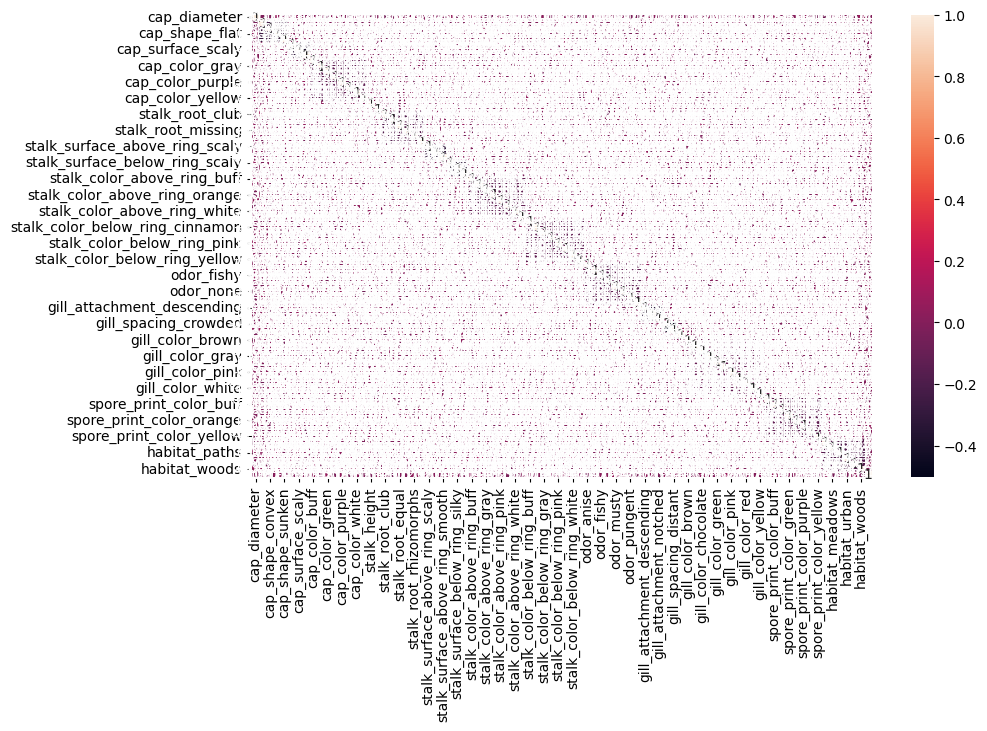

In [202]:
plt.figure(figsize=(10,6))
sns.heatmap(mushroom_df5.corr(),annot=True)
plt.show()

In [203]:
filtered_corr = corr_matrix.where(corr_matrix.abs() > 0.2)
filtered_corr = filtered_corr.dropna(how='all').dropna(axis=1, how='all')

In [204]:
filtered_corr

,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,stalk_height,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class_poisonous
cap_diameter,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_shape_conical,NaN,1.000000,-0.236894,-0.251254,-0.264678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_shape_convex,NaN,-0.236894,1.000000,-0.241475,-0.254376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_shape_flat,NaN,-0.251254,-0.241475,1.000000,-0.269796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cap_shape_sunken,NaN,-0.264678,-0.254376,-0.269796,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

# Step 3 - Model building

##  Step 3.1 - find out independent and dependent variable

In [205]:
mushroom_df5.head()

,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,stalk_height,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods,class
0,0.166667,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0.923077,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
1,0.750000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0.076923,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0.250000,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0.538462,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1
3,0.791667,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0.230769,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0.458333,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0.923077,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1


- dependent vriable - class

##  Step 3.2 split the data into X-train and Y-train

In [206]:
from sklearn.model_selection import train_test_split

In [226]:
mushroom_df5.iloc[:,0:-1]

,cap_diameter,cap_shape_conical,cap_shape_convex,cap_shape_flat,cap_shape_sunken,cap_surface_grooves,cap_surface_scaly,cap_surface_smooth,cap_color_buff,cap_color_gray,cap_color_green,cap_color_pink,cap_color_purple,cap_color_red,cap_color_white,cap_color_yellow,stalk_height,stalk_shape_tapering,stalk_root_club,stalk_root_cup,stalk_root_equal,stalk_root_missing,stalk_root_rhizomorphs,stalk_root_rooted,stalk_surface_above_ring_scaly,stalk_surface_above_ring_silky,stalk_surface_above_ring_smooth,stalk_surface_below_ring_scaly,stalk_surface_below_ring_silky,stalk_surface_below_ring_smooth,stalk_color_above_ring_buff,stalk_color_above_ring_cinnamon,stalk_color_above_ring_gray,stalk_color_above_ring_orange,stalk_color_above_ring_pink,stalk_color_above_ring_red,stalk_color_above_ring_white,stalk_color_above_ring_yellow,stalk_color_below_ring_buff,stalk_color_below_ring_cinnamon,stalk_color_below_ring_gray,stalk_color_below_ring_orange,stalk_color_below_ring_pink,stalk_color_below_ring_red,stalk_color_below_ring_white,stalk_color_below_ring_yellow,odor_anise,odor_creosote,odor_fishy,odor_foul,odor_musty,odor_none,odor_pungent,odor_spicy,gill_attachment_descending,gill_attachment_free,gill_attachment_notched,gill_spacing_crowded,gill_spacing_distant,gill_size_narrow,gill_color_brown,gill_color_buff,gill_color_chocolate,gill_color_gray,gill_color_green,gill_color_orange,gill_color_pink,gill_color_purple,gill_color_red,gill_color_white,gill_color_yellow,spore_print_color_brown,spore_print_color_buff,spore_print_color_chocolate,spore_print_color_green,spore_print_color_orange,spore_print_color_purple,spore_print_color_white,spore_print_color_yellow,habitat_leaves,habitat_meadows,habitat_paths,habitat_urban,habitat_waste,habitat_woods
0,0.166667,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0.923077,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,0.750000,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0.076923,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0.250000,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0.538462,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,0.791667,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0.230769,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0.458333,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0.923077,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.333333,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.846154,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1988,0.708333,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0.076923,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1989,0.583333,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0.846154,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1996,0.500000,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.307692,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [207]:
x=mushroom_df5.iloc[:,:-1]
y=mushroom_df5.iloc[:,-1]

In [208]:
x.shape,y.shape

((976, 85), (976,))

In [224]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: class, dtype: int64

In [209]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=72)

In [210]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((780, 85), (196, 85), (780,), (196,))

### 3.2.1 Regularize the model

- You don’t add regularization separately (like in linear regression)
- You control it using C

# Step 5 - Choose the Algorithm and Build the model

## Step 5.1 – Find the best parameter

In [227]:
from sklearn.svm import SVC
SVC_class=SVC(class_weight='balanced')

In [228]:
'''svc_params={'C':[0.6,1,1.5],
           'gamma':[0.002,0.005,0.007],
           'kernel':['linear','rbf']
          }''' # for this combination it is giving 65% accuracy and f1 score is 65%. SO chnging the conbinsation
         

In [246]:
''' svc_params={
    'kernel': ['rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1]
}''' # for this combination it is giving 65% accuracy and f1 score is 65%. SO chnging the conbinsation

In [266]:
'''svc_params={'C':[0.1,0.6,1,1.5,3],
           'gamma':[0.001,0.002,0.005,0.007],
           'kernel':['linear','rbf','poly']
          }''' # this combination is also biased towrd the class 1. so the better combination is below

In [286]:
svc_params={'C':[0.6,1,1.5],
           'gamma':[0.002,0.005,0.007],
           'kernel':['linear','rbf']
          }

In [287]:
from sklearn.model_selection import GridSearchCV

In [288]:
grid_model=GridSearchCV(estimator=SVC(class_weight='balanced'),## this filed should be object not the real class
                       param_grid=svc_params,
                       scoring='accuracy',
                       cv=2)

In [289]:
grid_model.fit(x_train,y_train)

GridSearchCV(cv=2, estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.6, 1, 1.5], 'gamma': [0.002, 0.005, 0.007],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [290]:
grid_model.best_estimator_

SVC(C=1, class_weight='balanced', gamma=0.002, kernel='linear')

In [291]:
grid_model.best_score_

np.float64(0.4987179487179487)

In [292]:
grid_model.best_params_

{'C': 1, 'gamma': 0.002, 'kernel': 'linear'}

# Step 6 -Train the Model

In [293]:
svc_final_model=SVC(C= 1, gamma= 0.002, kernel= 'linear') # INititqalize the model

In [294]:
svc_final_model.fit(x_train,y_train) # train the model

SVC(C=1, gamma=0.002, kernel='linear')

# Step 7 - Evaluate the Model

In [295]:
from sklearn.metrics import classification_report,confusion_matrix

In [296]:
y_hat_train=svc_final_model.predict(x_train)

In [297]:
train_cm=confusion_matrix(y_train,y_hat_train)
print(train_cm)

[[ 31 258]
 [ 15 476]]


In [298]:
train_cr=classification_report(y_train,y_hat_train)
print(train_cr)

              precision    recall  f1-score   support

           0       0.67      0.11      0.19       289
           1       0.65      0.97      0.78       491

    accuracy                           0.65       780
   macro avg       0.66      0.54      0.48       780
weighted avg       0.66      0.65      0.56       780



In [299]:
''' y_hat_train_g=grid_model.predict(x_train)

train_cm_g=confusion_matrix(y_train,y_hat_train_g)
print(train_cm_g) ''' # we can use the model created to find out best aparm to predict, in above case the model is grid_model

' y_hat_train_g=grid_model.predict(x_train)\n\ntrain_cm_g=confusion_matrix(y_train,y_hat_train_g)\nprint(train_cm_g) '

#### predict the data for test

In [300]:
y_hat_test=svc_final_model.predict(x_test)

In [301]:
test_cm=confusion_matrix(y_test,y_hat_test)
print(test_cm)

[[  7  62]
 [ 10 117]]


In [302]:
test_cr=classification_report(y_test,y_hat_test)
print(test_cr)

              precision    recall  f1-score   support

           0       0.41      0.10      0.16        69
           1       0.65      0.92      0.76       127

    accuracy                           0.63       196
   macro avg       0.53      0.51      0.46       196
weighted avg       0.57      0.63      0.55       196



- Summary
- Train accuracy - 100%
- Test accuracy - 63%
- Model is not giving good output but it is performing similar way for train and test.
- Model is not performing good may be because of imbalanced data